## Cleaning the data and EDA

### Loading the data

In [4]:
import os
import pandas as pd
import numpy as np

path = r"C:\Users\nisha\Desktop\2026 PS-II\Projects\Loan\scientificProject\data"
import_file = os.path.join(path, 'loan_data.csv')

Data=pd.read_csv(import_file)
Data=Data.dropna(axis=0,how='any')
print(Data)

      credit.policy             purpose  int.rate  installment  \
0                 1  debt_consolidation    0.1189       829.10   
1                 1         credit_card    0.1071       228.22   
2                 1  debt_consolidation    0.1357       366.86   
3                 1  debt_consolidation    0.1008       162.34   
4                 1         credit_card    0.1426       102.92   
...             ...                 ...       ...          ...   
9573              0           all_other    0.1461       344.76   
9574              0           all_other    0.1253       257.70   
9575              0  debt_consolidation    0.1071        97.81   
9576              0    home_improvement    0.1600       351.58   
9577              0  debt_consolidation    0.1392       853.43   

      log.annual.inc    dti  fico  days.with.cr.line  revol.bal  revol.util  \
0          11.350407  19.48   737        5639.958333      28854        52.1   
1          11.082143  14.29   707        2760.000

As we can see the data is already in a cleaned format so we will be going ahead with EDA

### EDA

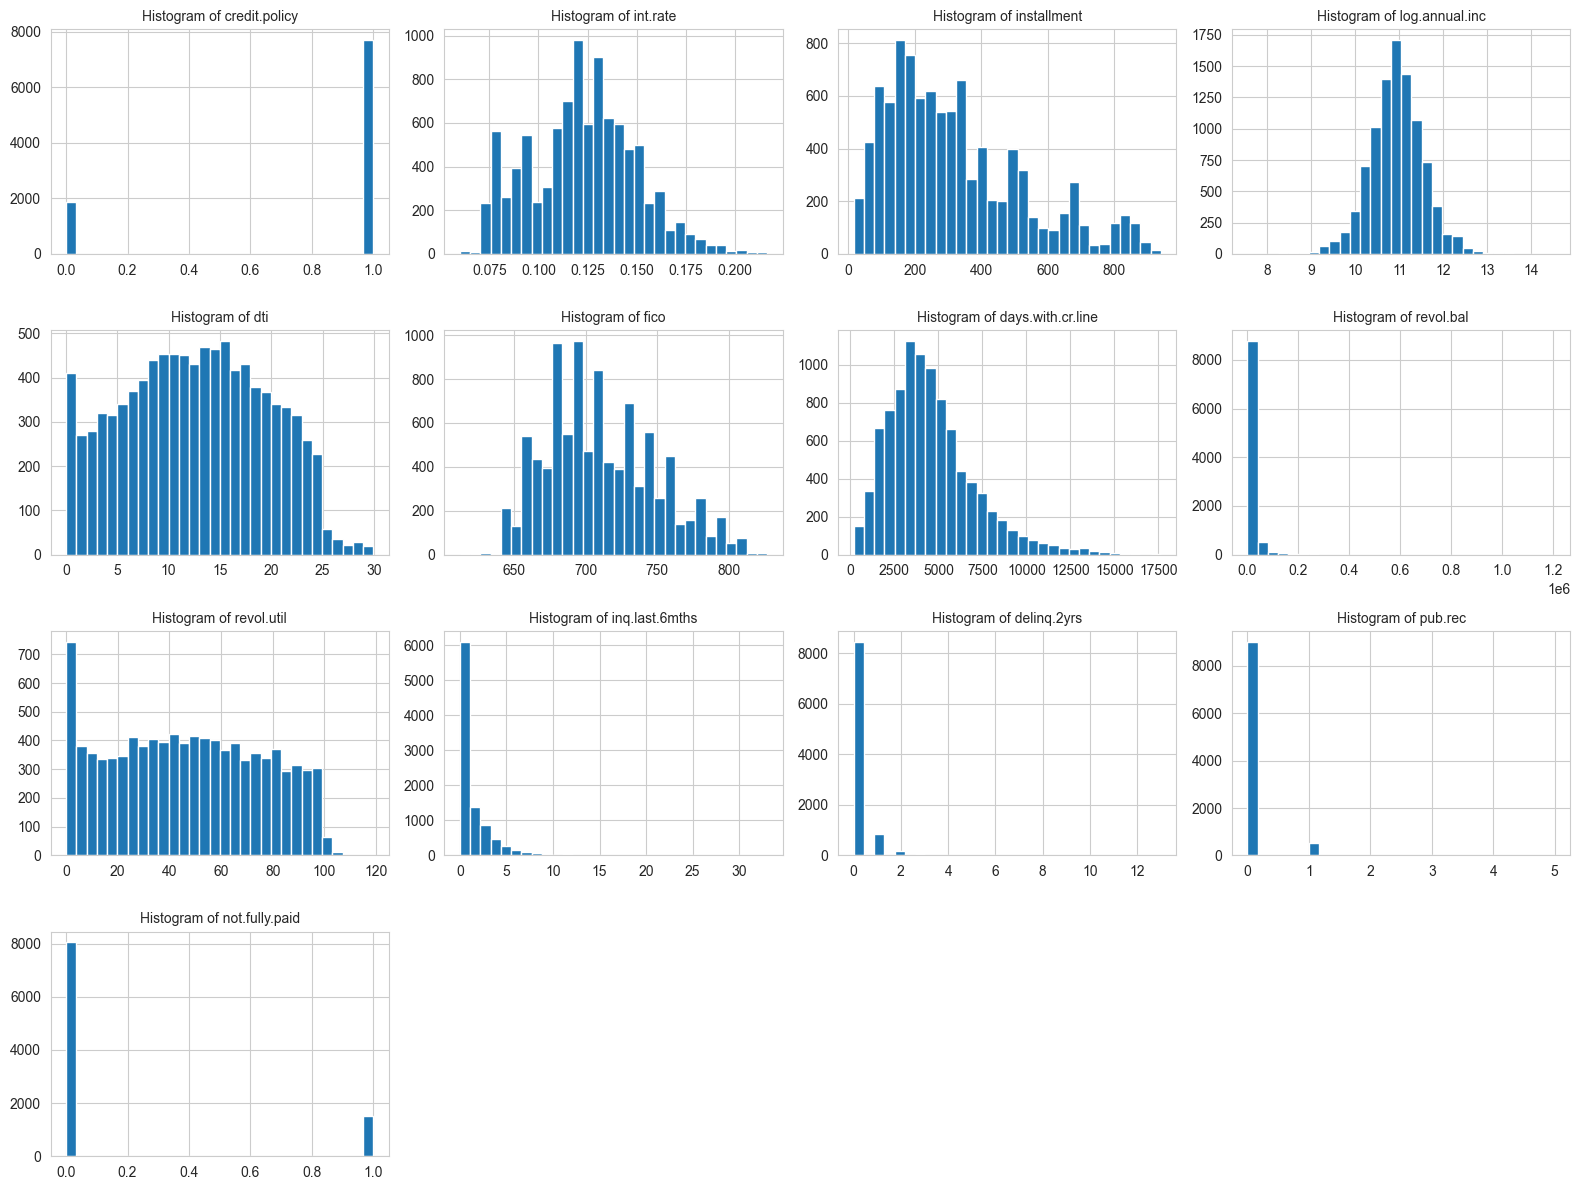

In [5]:
import matplotlib.pyplot as plt

# Histogram for all numerical features (int and float)
numeric_cols = Data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    plt.hist(Data[col], bins=30)
    plt.title(f"Histogram of {col}", fontsize=10)

# Apply tight_layout once after all subplots are drawn
plt.tight_layout()
plt.show()

ValueError: num must be an integer with 1 <= num <= 12, not 13

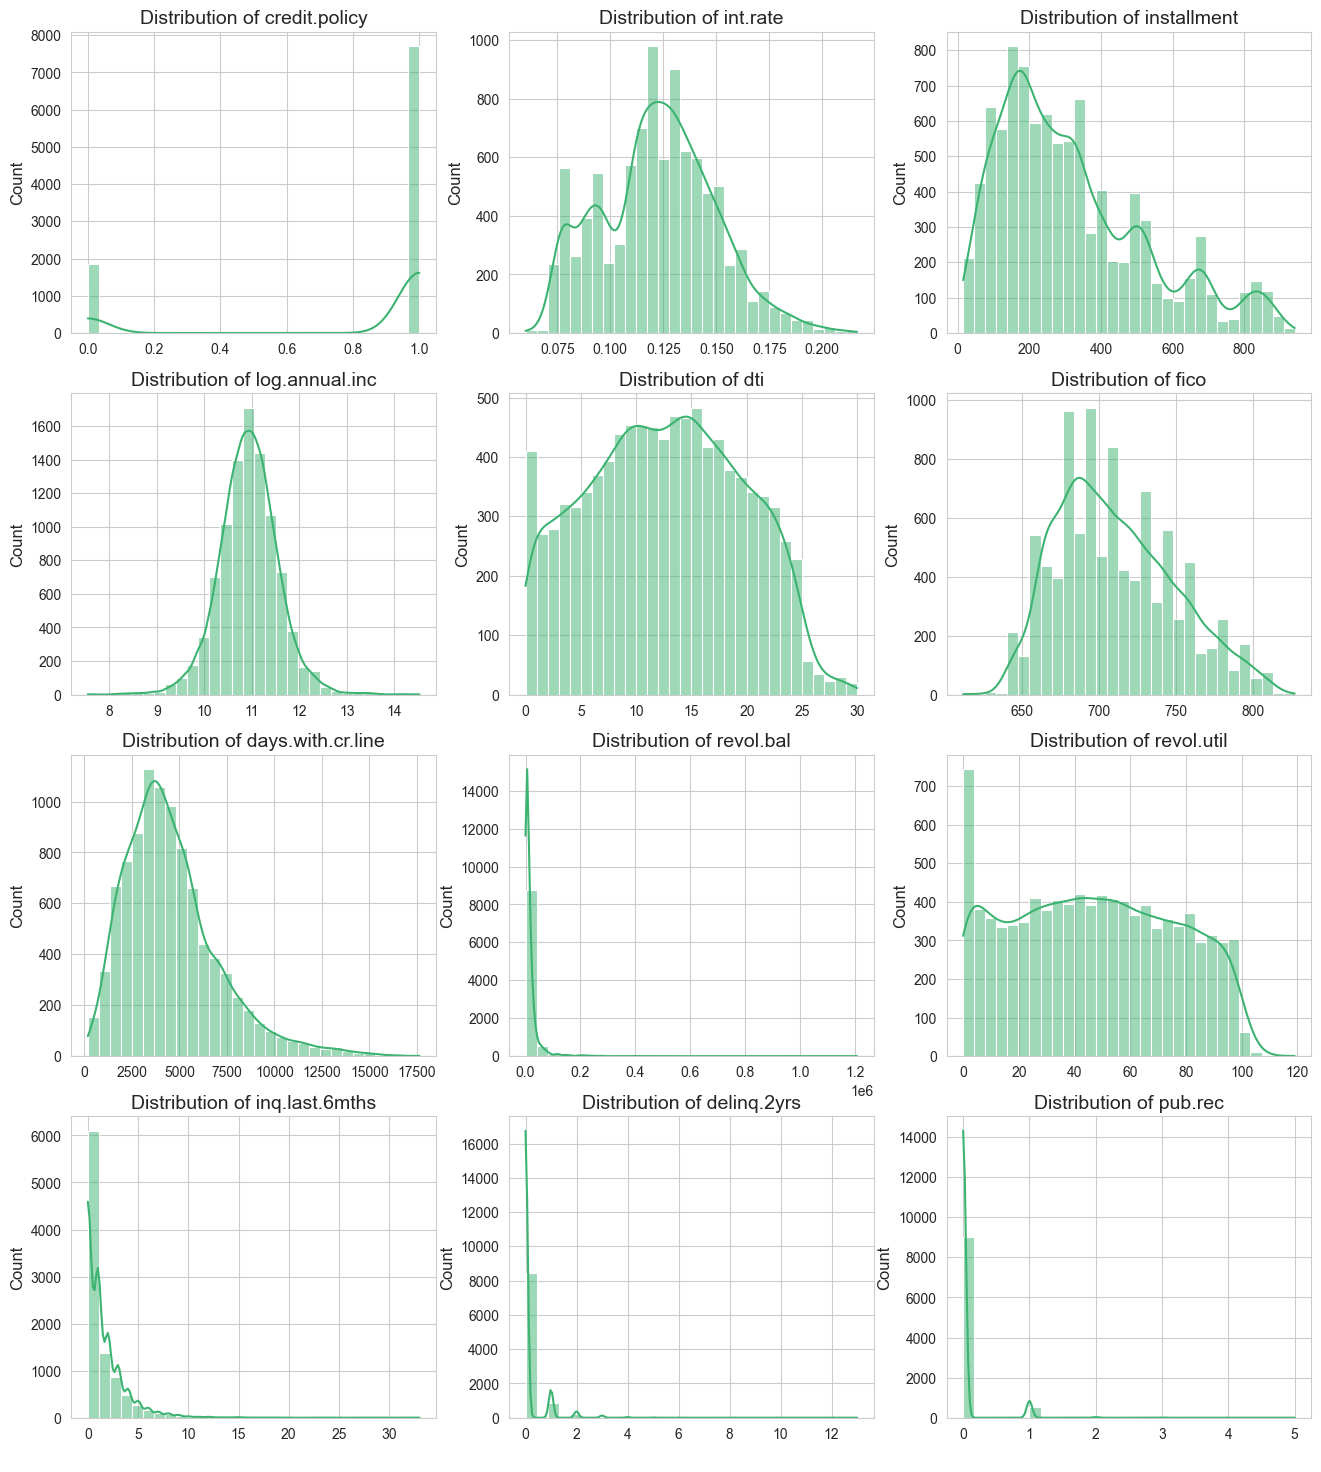

In [6]:
import seaborn as sns

# Style Settings
plt.style.use("default")
sns.set_style("whitegrid")

# Find all numerical columns
numeric_cols = Data.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure grid
plt.figure(figsize=(16, 18))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    
    sns.histplot(data=Data, x=col, kde=True, bins=30, color='mediumseagreen')
    
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(" ", fontsize=12)
    plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

### Adding new feature

In [ ]:
Data['revol.bal.log'] = np.log1p(Data['revol.bal'])

### Correlation Testing

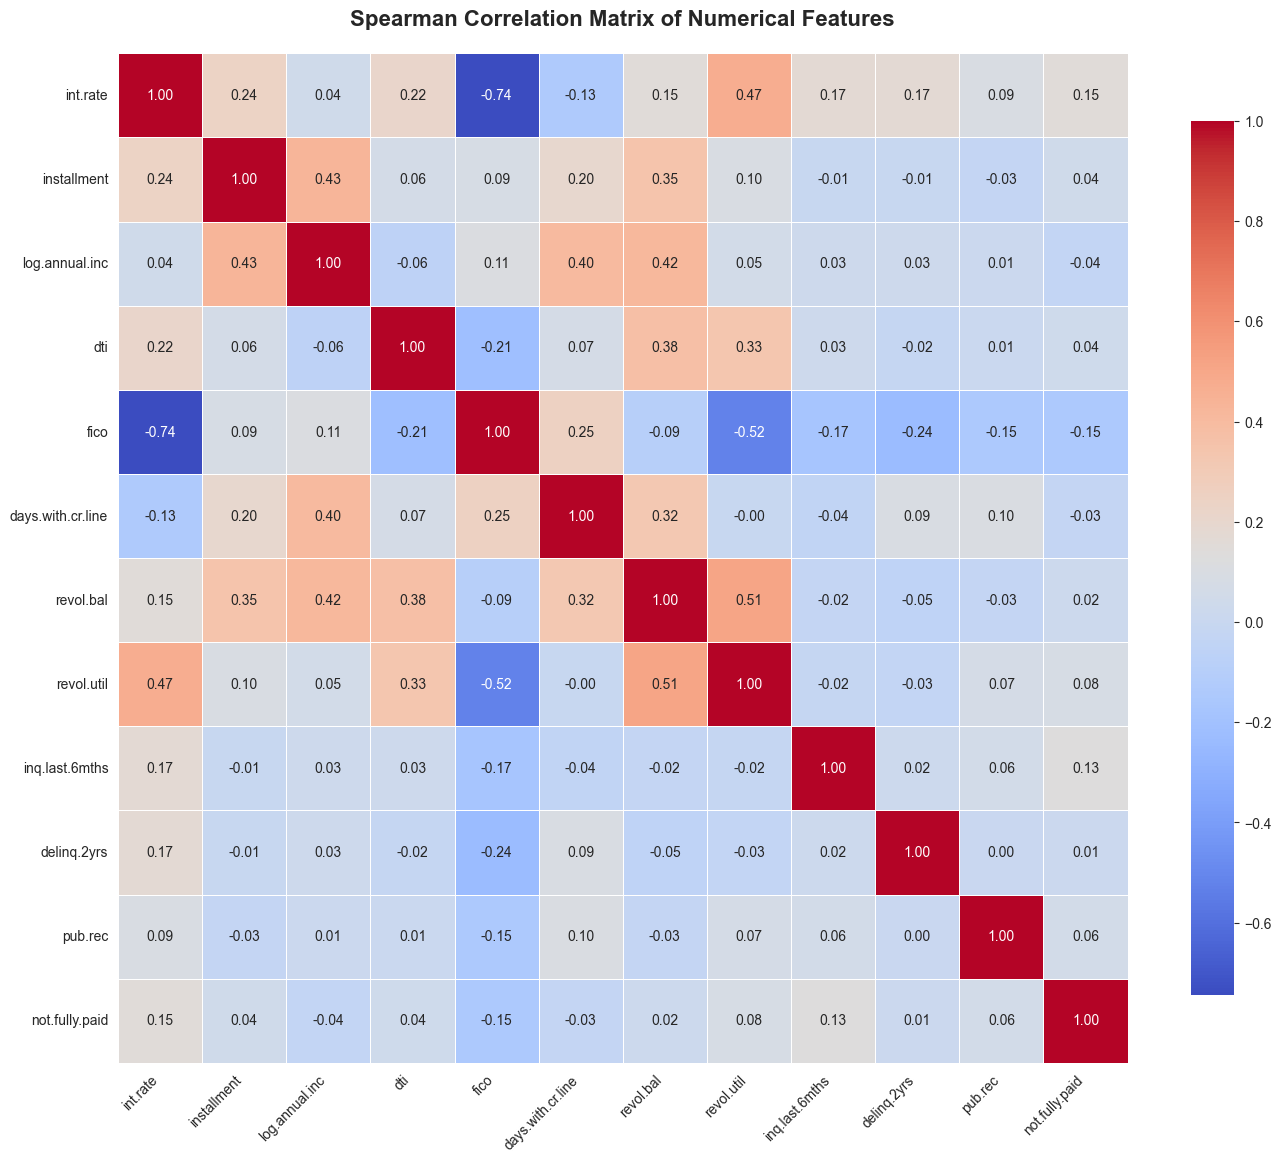

  Feature 1          Feature 2  Spearman Correlation        p-value
0  int.rate        installment              0.242914  1.139489e-128
1  int.rate     log.annual.inc              0.041648   4.557619e-05
2  int.rate                dti              0.216114  1.306209e-101
3  int.rate               fico             -0.744986   0.000000e+00
4  int.rate  days.with.cr.line             -0.133584   2.196199e-39
5  int.rate          revol.bal              0.148719   1.698967e-48
6  int.rate         revol.util              0.472965   0.000000e+00
7  int.rate     inq.last.6mths              0.174137   4.342351e-66
8  int.rate        delinq.2yrs              0.172677   5.331970e-65
9  int.rate            pub.rec              0.093887   3.335608e-20


In [7]:
from scipy.stats import spearmanr

# 1) Select numerical features
num_cols = Data.select_dtypes(include=[np.number]).columns.drop('credit.policy')
numeric_df = Data[num_cols]

# 2) Calculate Spearman correlation matrix
spearman_corr = numeric_df.corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    linecolor="white",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Spearman Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold",
    pad=20
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 3) Spearman statistical test (to get p-values)
corr_results = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        col1 = num_cols[i]
        col2 = num_cols[j]
        # Calculate correlation and p-value, drop missing values to avoid NaNs
        corr, pval = spearmanr(Data[col1].dropna(), Data[col2].dropna())
        corr_results.append([col1, col2, corr, pval])

# Convert results into a readable DataFrame
spearman_results_df = pd.DataFrame(
    corr_results,
    columns=["Feature 1", "Feature 2", "Spearman Correlation", "p-value"]
)

# Display the top 10 feature pairs
print(spearman_results_df.head(10))

### Preparing the data for modelling 

In [8]:
import pandas as pd

# 1) Check unique categories before encoding
print("Unique categories in 'purpose':")
print(Data['purpose'].unique())

# 2) One-hot encode the 'purpose' column
purpose_dummies = pd.get_dummies(Data['purpose'], prefix='purpose', drop_first=True)

# 3) Add the new encoded columns to the main dataframe
Data = pd.concat([Data, purpose_dummies], axis=1)

# 4) Remove the original text column since it's no longer needed
Data.drop(columns=['purpose'], inplace=True)

# 5) Show the result to verify
print("\nFirst 5 rows after encoding:")
print(Data.head())

Unique categories in 'purpose':
['debt_consolidation' 'credit_card' 'all_other' 'home_improvement'
 'small_business' 'major_purchase' 'educational']

First 5 rows after encoding:
   credit.policy  int.rate  installment  log.annual.inc    dti  fico  \
0              1    0.1189       829.10       11.350407  19.48   737   
1              1    0.1071       228.22       11.082143  14.29   707   
2              1    0.1357       366.86       10.373491  11.63   682   
3              1    0.1008       162.34       11.350407   8.10   712   
4              1    0.1426       102.92       11.299732  14.97   667   

   days.with.cr.line  revol.bal  revol.util  inq.last.6mths  delinq.2yrs  \
0        5639.958333      28854        52.1               0            0   
1        2760.000000      33623        76.7               0            0   
2        4710.000000       3511        25.6               1            0   
3        2699.958333      33667        73.2               1            0   
4       

In [9]:
# 1) Define the list of features you want to remove
features_to_drop = ['revol.bal', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

# 2) Drop the columns from the dataframe
Data.drop(columns=features_to_drop, inplace=True)

# 3) Show the result to verify they are gone
print(f"Columns remaining: {len(Data.columns)}")
print(Data.head())

export_file = os.path.join(path, 'final_data.csv')
Data.to_csv(export_file)


Columns remaining: 15
   credit.policy  int.rate  installment  log.annual.inc    dti  fico  \
0              1    0.1189       829.10       11.350407  19.48   737   
1              1    0.1071       228.22       11.082143  14.29   707   
2              1    0.1357       366.86       10.373491  11.63   682   
3              1    0.1008       162.34       11.350407   8.10   712   
4              1    0.1426       102.92       11.299732  14.97   667   

   days.with.cr.line  revol.util  not.fully.paid  purpose_credit_card  \
0        5639.958333        52.1               0                False   
1        2760.000000        76.7               0                 True   
2        4710.000000        25.6               0                False   
3        2699.958333        73.2               0                False   
4        4066.000000        39.5               0                 True   

   purpose_debt_consolidation  purpose_educational  purpose_home_improvement  \
0                        T